# 03 — Exploratory Data Analysis & Dataset Limitations

**COMP8420 Use Case 3 — Research Paper Analysis & Recommendation System**  
Owner: *Yash* · Track: Dataset, EDA, Preprocessing, Classification

This notebook implements **Stage 03** of the data-foundation workstream.
It performs a thorough EDA on the filtered arXiv corpus produced in Stage 01,
then produces a written limitations analysis for the project report.

### What it covers
1. Corpus loading and basic statistics
2. Category distribution
3. Publication timeline (year / month trends)
4. Abstract length distribution
5. Author statistics (prolific authors, co-authorship)
6. Missing-data audit (DOI, venue, enrichment coverage)
7. Vocabulary analysis & word cloud
8. Citation distribution (post-enrichment)
9. Dataset limitations (report-ready Markdown)
10. Saving all figures and the limitations note

### Rubric evidence
- *Data selection and preparation* — justified dataset, documented characteristics.
- *Results presentation* — multifaceted visual + structured output.
- *Critical discussion* — documented limitations feeding the report's Discussion section.


## 1. Setup

In [1]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud

# ── Paths (mirror Stage 01 conventions) ─────────────────────────────────
CORPUS_PLAIN    = Path("data/processed/dev_5k.jsonl")          # unenriched
CORPUS_ENRICHED = Path("data/processed/dev_5k_enriched.jsonl") # post-S2
DEMO_CORPUS     = Path("data/processed/dev_sample.jsonl")      # 4-record demo
FIGURES_DIR     = Path("results/eda/figures"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LIMITS_MD       = Path("results/eda/dataset_limitations.md")

# ── Plotting style ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "savefig.bbox": "tight",
                     "savefig.dpi": 150, "figure.figsize": (9, 4)})
CATEGORY_PALETTE = {
    "cs.CL": "#4C72B0", "cs.AI": "#DD8452",
    "cs.LG": "#55A868", "stat.ML": "#C44E52",
}
# ── Local .env support (VSCode) ─────────────────────────────────────────
try:
    from dotenv import load_dotenv
    load_dotenv(dotenv_path=Path(".env"), override=False)
except ImportError:
    pass   # install python-dotenv or set env vars manually

print("Setup complete. Figures will be saved to:", FIGURES_DIR)


Setup complete. Figures will be saved to: results\eda\figures


## 2. Load corpus

We load whichever corpus is available: enriched (post-S2) → plain (post-Stage 01)
→ demo (4-record sample). This keeps the notebook runnable at every project stage.


In [2]:
def load_corpus(paths: list[Path]) -> tuple:
    for p in paths:
        if not p.exists():
            print(f"  skip (not found): {p.name}")
            continue
        lines = [l for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]
        if not lines:
            print(f"  skip (empty file): {p.name}")
            continue
        records = [json.loads(l) for l in lines]
        df = pd.DataFrame(records)
        if df.empty or "abstract" not in df.columns:
            print(f"  skip (no usable data): {p.name}")
            continue
        print(f"Loaded {len(df):,} records from {p.name}")
        return df, p
    raise FileNotFoundError(
        "No usable corpus found. Run Stage 01 (prepare_subset) first."
    )

df, corpus_path = load_corpus([CORPUS_ENRICHED, CORPUS_PLAIN, DEMO_CORPUS])

# ── Derived columns ───────────────────────────────────────────────────────
df["abstract_len"]   = df["abstract"].str.split().str.len()
df["title_len"]      = df["title"].str.split().str.len()
df["author_count"]   = df["authors"].apply(len)
df["category_count"] = df["categories"].apply(len)
df["primary_cat"]    = df["categories"].apply(lambda x: x[0] if x else "unknown")
df["year"]           = pd.to_datetime(df["published_date"], errors="coerce").dt.year
df["month"]          = pd.to_datetime(df["published_date"], errors="coerce").dt.month
df["has_doi"]        = df["doi"].notna() & (df["doi"] != "")
df["has_venue"]      = df["venue"].notna() & (df["venue"] != "")
df["has_tldr"]       = df["tldr"].apply(lambda x: bool(x)) if "tldr" in df.columns else False
df["ref_count"]      = df["references"].apply(len) if "references" in df.columns else 0
df["s2_enriched"]    = df.get("s2_enriched", pd.Series([False]*len(df)))

print("\nColumn overview:")
print(df[["paper_id","primary_cat","year","abstract_len","author_count",
          "has_doi","has_venue","s2_enriched"]].head(3).to_string())


  skip (empty file): dev_5k_enriched.jsonl
Loaded 5,000 records from dev_5k.jsonl

Column overview:
    paper_id primary_cat  year  abstract_len  author_count  has_doi  has_venue  s2_enriched
0  0704.0047       cs.NE  2007           169             2    False      False        False
1  0704.0050       cs.NE  2007           136             2    False      False        False
2  0704.0304       cs.IT  2007           116             1     True       True        False


## 3. Basic corpus statistics

In [3]:
total      = len(df)
n_cats     = df["primary_cat"].nunique()
year_range = f"{int(df['year'].min())} – {int(df['year'].max())}" if df['year'].notna().any() else "N/A"
multi_cat  = (df["category_count"] > 1).sum()

print("=" * 45)
print(f"  Total papers          : {total:,}")
print(f"  Unique primary cats   : {n_cats}")
print(f"  Year range            : {year_range}")
print(f"  Multi-category papers : {multi_cat:,} ({multi_cat/total*100:.1f}%)")
print(f"  Avg abstract length   : {df['abstract_len'].mean():.0f} words")
print(f"  Avg authors / paper   : {df['author_count'].mean():.1f}")
print(f"  Papers with DOI       : {df['has_doi'].sum():,} ({df['has_doi'].mean()*100:.1f}%)")
print(f"  Papers with venue     : {df['has_venue'].sum():,} ({df['has_venue'].mean()*100:.1f}%)")
print(f"  S2-enriched records   : {df['s2_enriched'].sum():,} ({df['s2_enriched'].mean()*100:.1f}%)")
print("=" * 45)


  Total papers          : 5,000
  Unique primary cats   : 88
  Year range            : 2007 – 2012
  Multi-category papers : 3,313 (66.3%)
  Avg abstract length   : 143 words
  Avg authors / paper   : 2.5
  Papers with DOI       : 1,098 (22.0%)
  Papers with venue     : 1,708 (34.2%)
  S2-enriched records   : 0 (0.0%)


## 4. Category distribution

We record a paper's **primary category** (first target category in the paper's own
list) as the single classification label used in Stages 05–06.


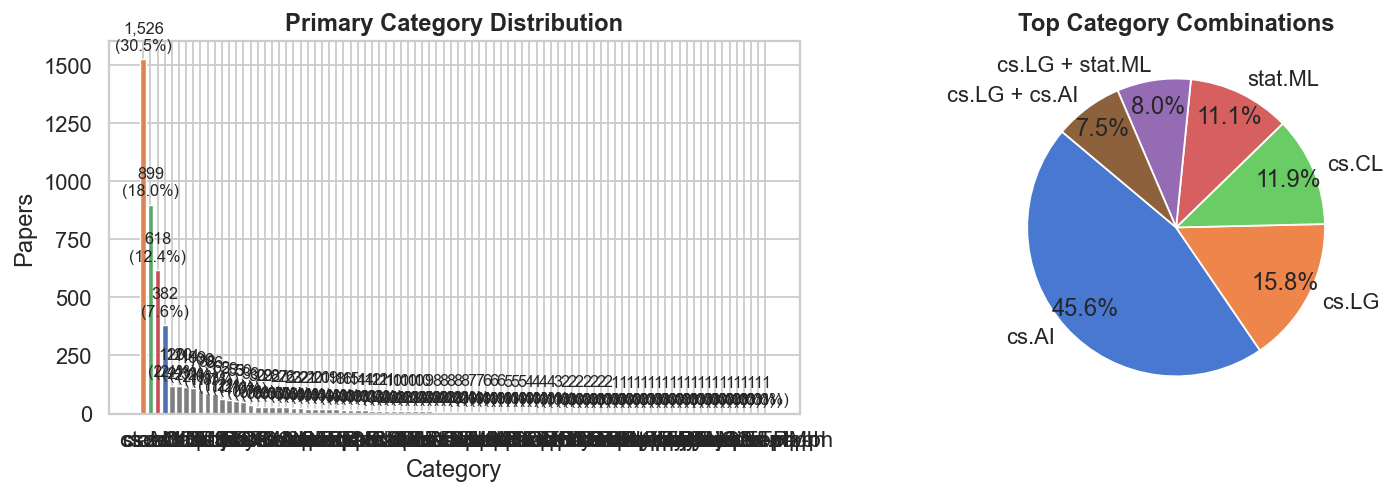

Saved: 01_category_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart – primary category
cat_counts = df["primary_cat"].value_counts()
colors     = [CATEGORY_PALETTE.get(c, "#7f7f7f") for c in cat_counts.index]
axes[0].bar(cat_counts.index, cat_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Primary Category Distribution", fontweight="bold")
axes[0].set_xlabel("Category"); axes[0].set_ylabel("Papers")
for bar, v in zip(axes[0].patches, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                 f"{v:,}\n({v/total*100:.1f}%)", ha="center", va="bottom", fontsize=9)

# Pie – multi-category breakdown
cat_combo = df["categories"].apply(lambda x: " + ".join(x[:2]) if len(x)>1 else x[0])
top_combos = cat_combo.value_counts().head(6)
axes[1].pie(top_combos.values, labels=top_combos.index, autopct="%1.1f%%",
            startangle=140, pctdistance=0.82,
            colors=sns.color_palette("muted", len(top_combos)))
axes[1].set_title("Top Category Combinations", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_category_distribution.png")
plt.show()
print("Saved: 01_category_distribution.png")


## 5. Publication timeline

Tracks how the corpus's NLP/AI/ML sub-fields have grown over the years —
relevant to the report's discussion of training data recency.


C:\Users\yashn\AppData\Local\Temp\ipykernel_27176\2645903850.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


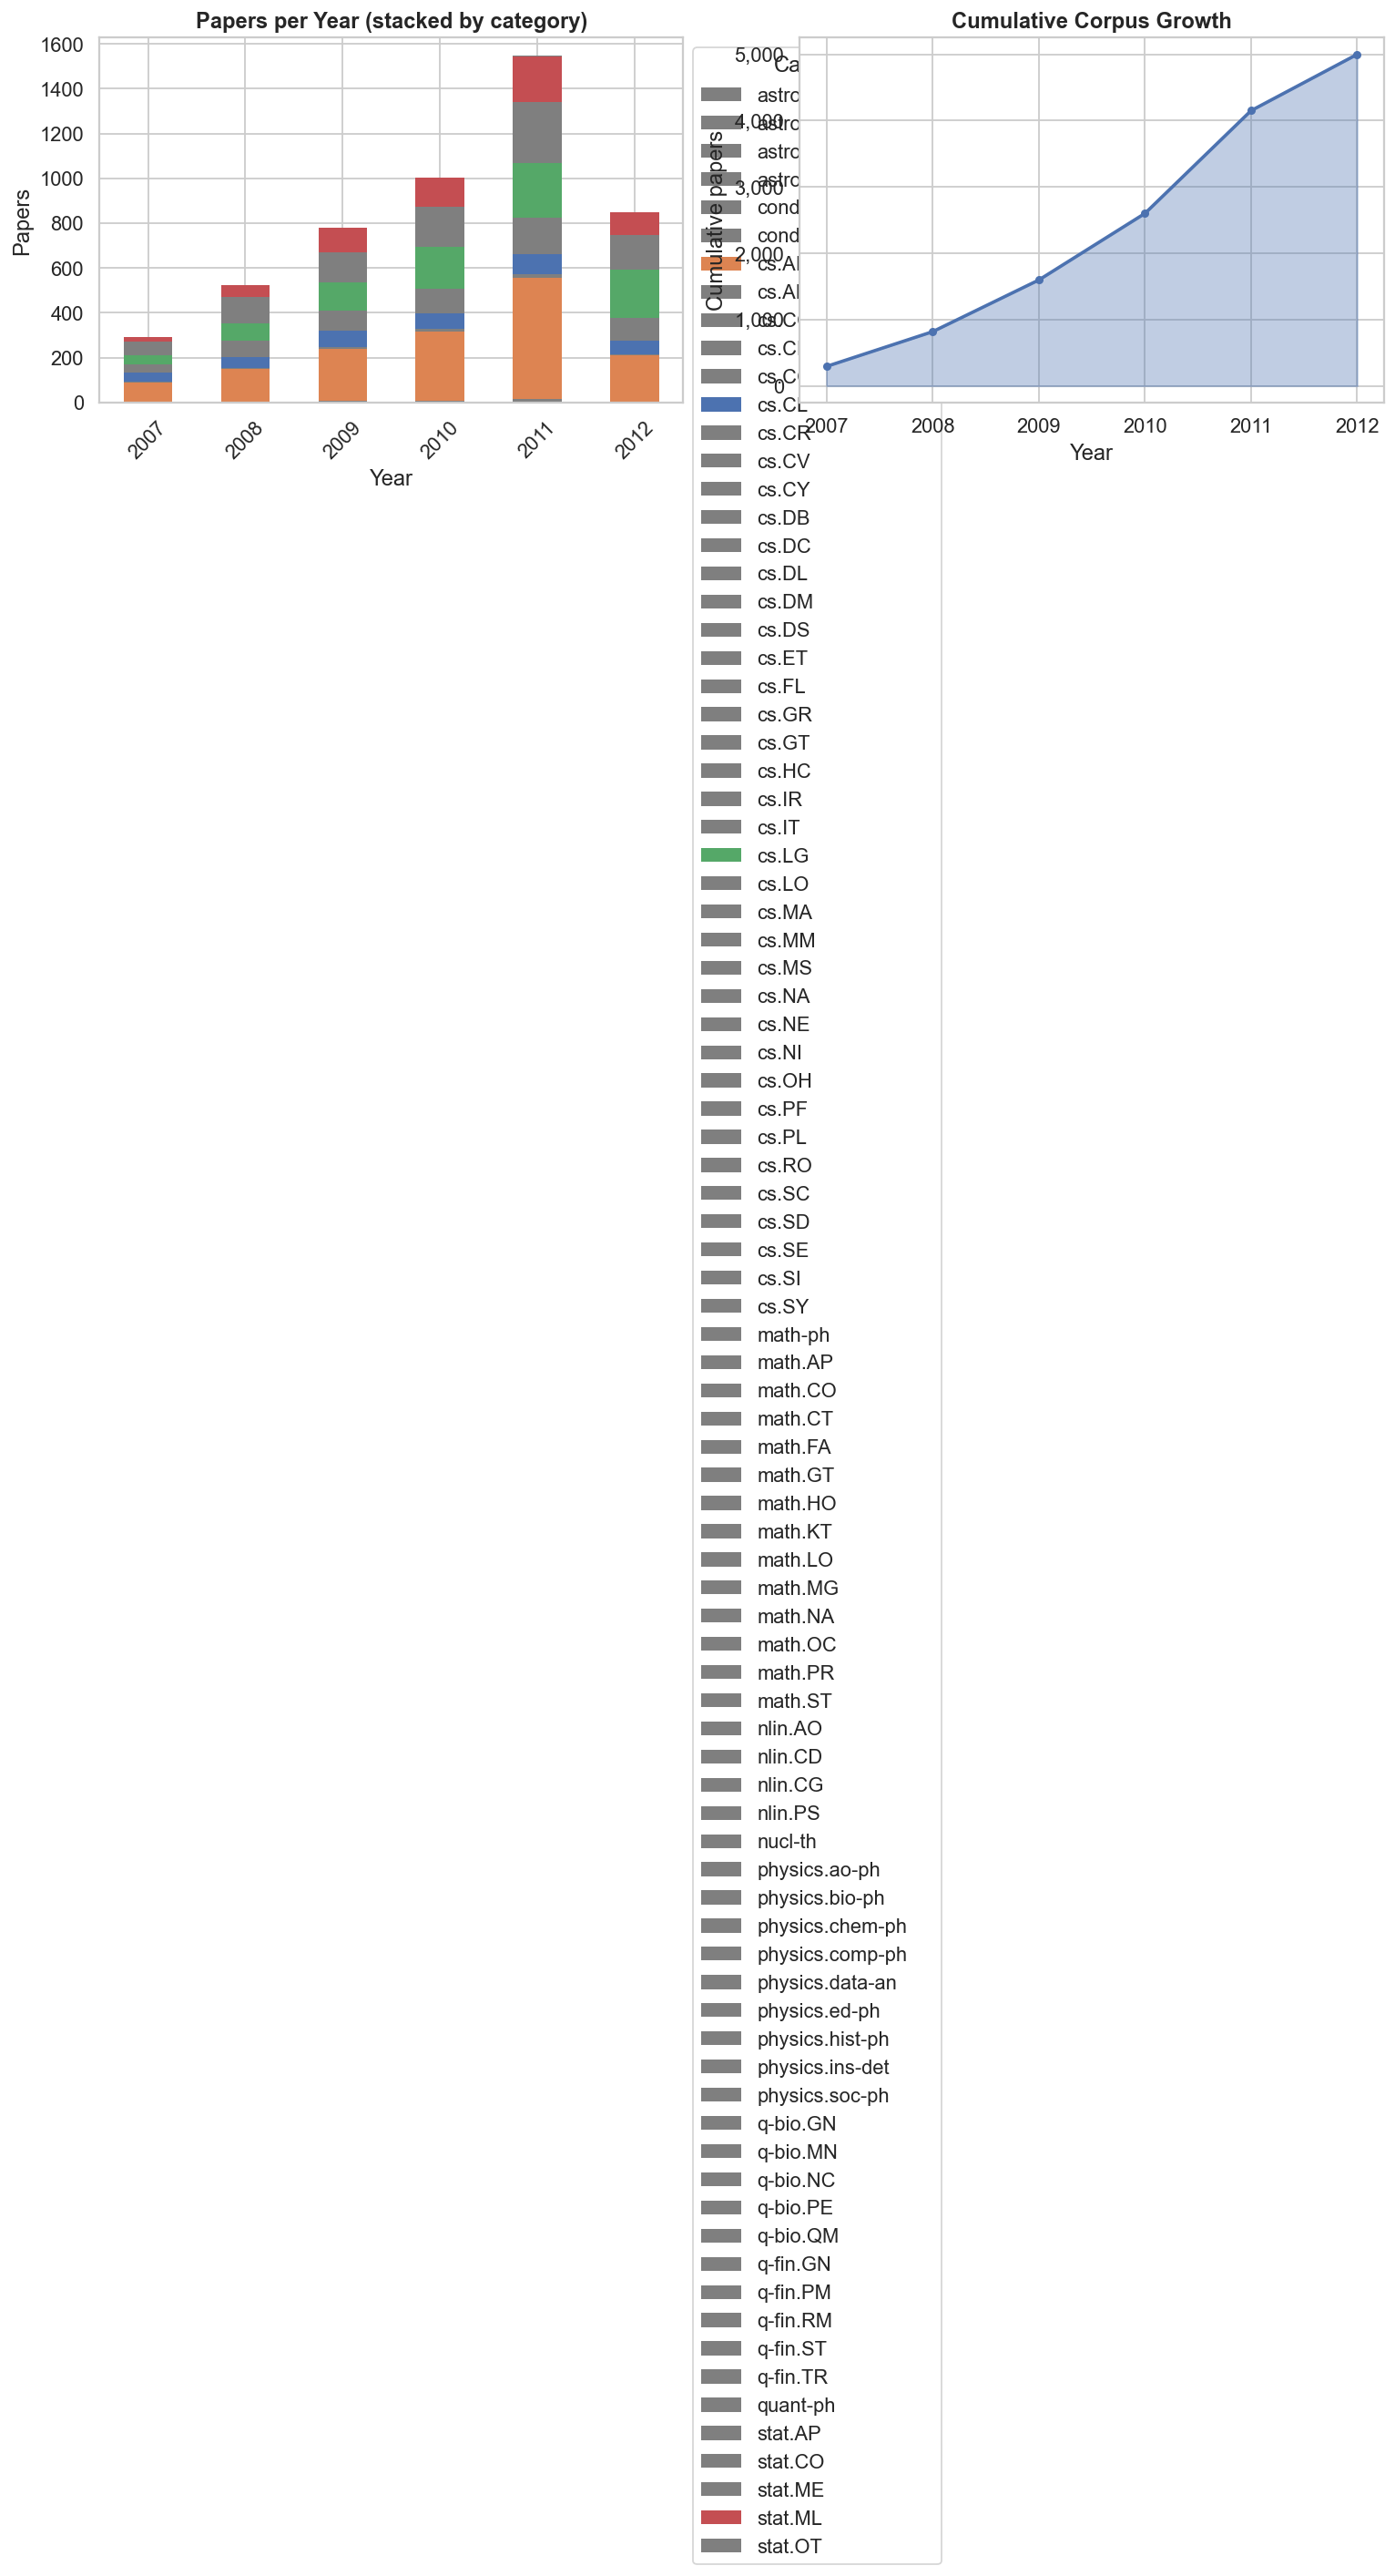

Saved: 02_publication_timeline.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Papers per year stacked by category
year_cat = df.groupby(["year","primary_cat"]).size().unstack(fill_value=0)
year_cat = year_cat[year_cat.index.notna()]
year_cat.plot(kind="bar", stacked=True, ax=axes[0],
              color=[CATEGORY_PALETTE.get(c,"#7f7f7f") for c in year_cat.columns],
              edgecolor="none")
axes[0].set_title("Papers per Year (stacked by category)", fontweight="bold")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Papers")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Category", bbox_to_anchor=(1,1))

# Cumulative growth
yearly_total = year_cat.sum(axis=1).sort_index()
cumulative   = yearly_total.cumsum()
axes[1].fill_between(cumulative.index.astype(int), cumulative.values,
                     alpha=0.35, color="#4C72B0")
axes[1].plot(cumulative.index.astype(int), cumulative.values,
             color="#4C72B0", linewidth=2, marker="o", markersize=4)
axes[1].set_title("Cumulative Corpus Growth", fontweight="bold")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Cumulative papers")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_publication_timeline.png")
plt.show()
print("Saved: 02_publication_timeline.png")


## 6. Abstract length distribution

Abstract length directly affects tokeniser truncation decisions in Stages 04–06
and the LLM prompt budgets in Mulkraj's adapter work.


C:\Users\yashn\AppData\Local\Temp\ipykernel_27176\1539559136.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=cat_order, patch_artist=True, notch=True,


Abstract length stats:
                     mean  median    std  min  max
primary_cat                                       
astro-ph            230.0   230.0    NaN  230  230
astro-ph.CO         203.5   205.5   48.4  152  251
astro-ph.GA          77.0    77.0    NaN   77   77
astro-ph.IM         186.2   169.5   58.1  122  278
cond-mat.dis-nn     144.2   143.0   60.4   57  267
cond-mat.stat-mech  149.4   159.0   60.2   60  247
cs.AI               139.3   134.0   58.4    3  414
cs.AR                98.5    98.5   41.7   69  128
cs.CC               166.6   150.0   71.2   75  290
cs.CE               144.3   138.0   53.3   74  239
cs.CG               173.5   162.5   58.8  107  246
cs.CL               126.8   121.5   54.7    8  317
cs.CR               150.2   152.0   67.7   14  279
cs.CV               149.5   149.5   58.4   10  306
cs.CY               130.2   115.5   43.8   72  205
cs.DB               170.0   173.5   57.8   11  283
cs.DC               166.8   171.0   75.5   70  295
cs.DL   

C:\Users\yashn\AppData\Local\Temp\ipykernel_27176\1539559136.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


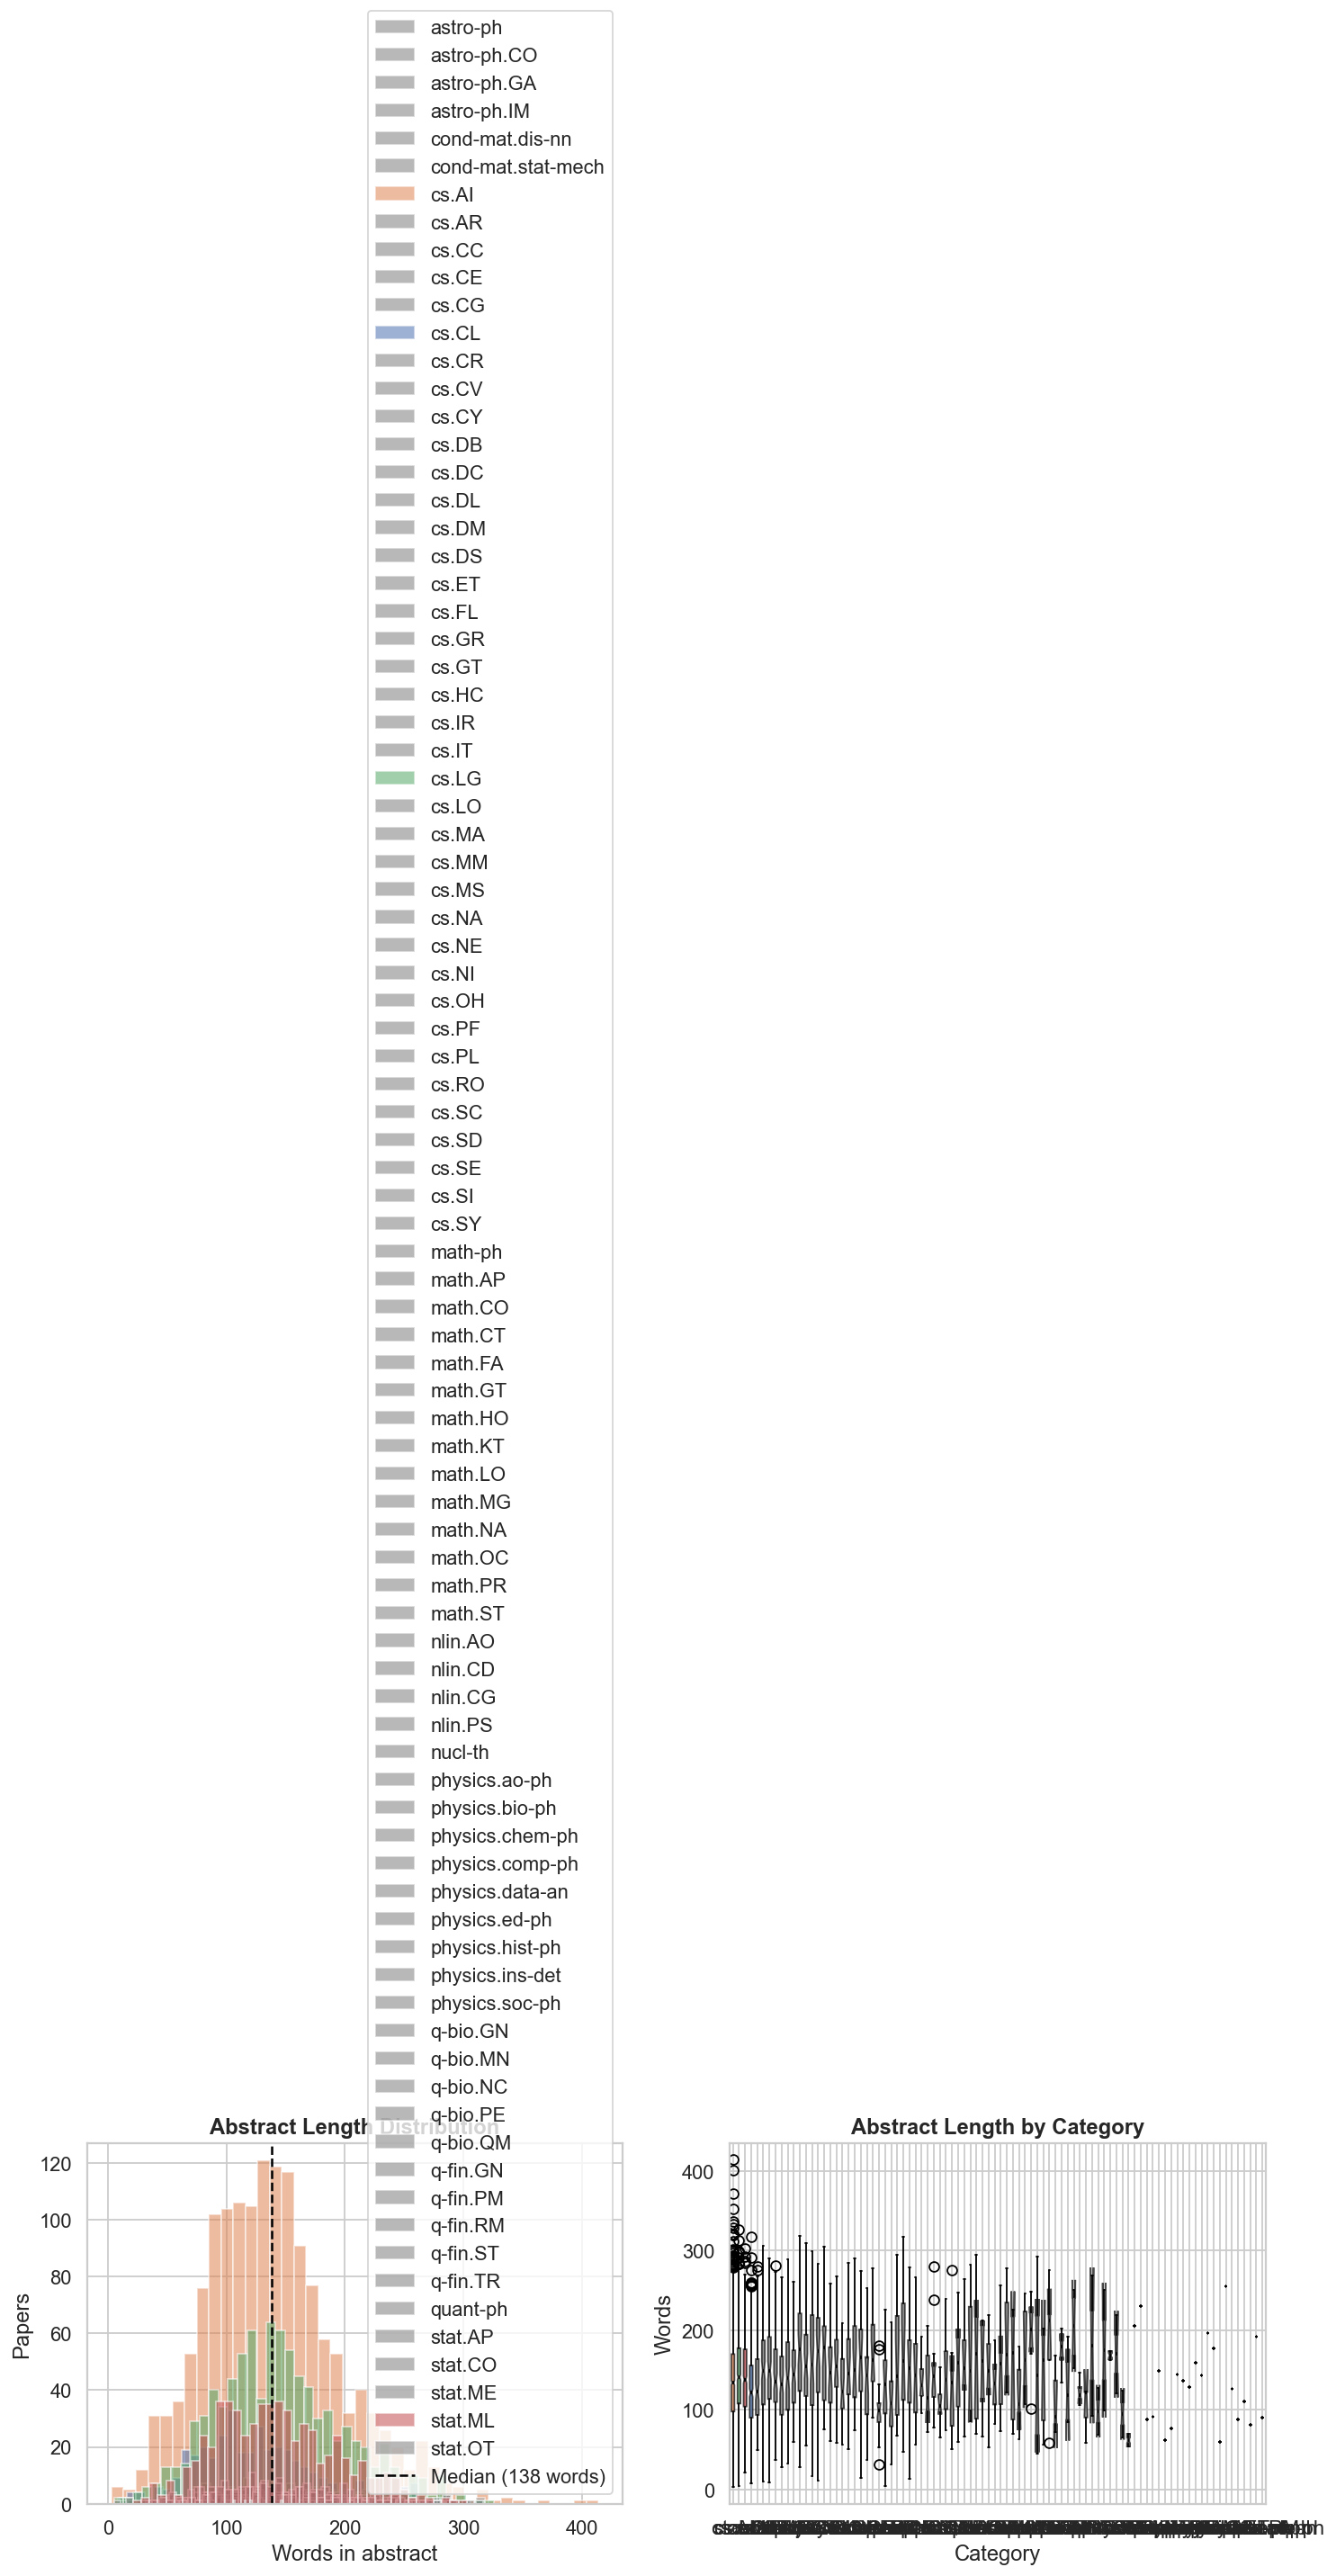


Saved: 03_abstract_length.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram by category
for cat, grp in df.groupby("primary_cat"):
    axes[0].hist(grp["abstract_len"], bins=40, alpha=0.55,
                 label=cat, color=CATEGORY_PALETTE.get(cat,"#7f7f7f"))
axes[0].axvline(df["abstract_len"].median(), color="black", linestyle="--",
                linewidth=1.4, label=f"Median ({int(df['abstract_len'].median())} words)")
axes[0].set_title("Abstract Length Distribution", fontweight="bold")
axes[0].set_xlabel("Words in abstract"); axes[0].set_ylabel("Papers")
axes[0].legend()

# Box plot by category
cat_order = df["primary_cat"].value_counts().index.tolist()
bp_data   = [df[df["primary_cat"]==c]["abstract_len"].dropna().values for c in cat_order]
bp = axes[1].boxplot(bp_data, labels=cat_order, patch_artist=True, notch=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, cat in zip(bp["boxes"], cat_order):
    patch.set_facecolor(CATEGORY_PALETTE.get(cat,"#7f7f7f"))
    patch.set_alpha(0.7)
axes[1].set_title("Abstract Length by Category", fontweight="bold")
axes[1].set_xlabel("Category"); axes[1].set_ylabel("Words")

# Stats table
print("Abstract length stats:")
print(df.groupby("primary_cat")["abstract_len"]
        .agg(["mean","median","std","min","max"])
        .round(1).to_string())

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_abstract_length.png")
plt.show()
print("\nSaved: 03_abstract_length.png")


## 7. Author statistics

Unique authors: 7,625
Single-author papers: 1,063 (21.3%)


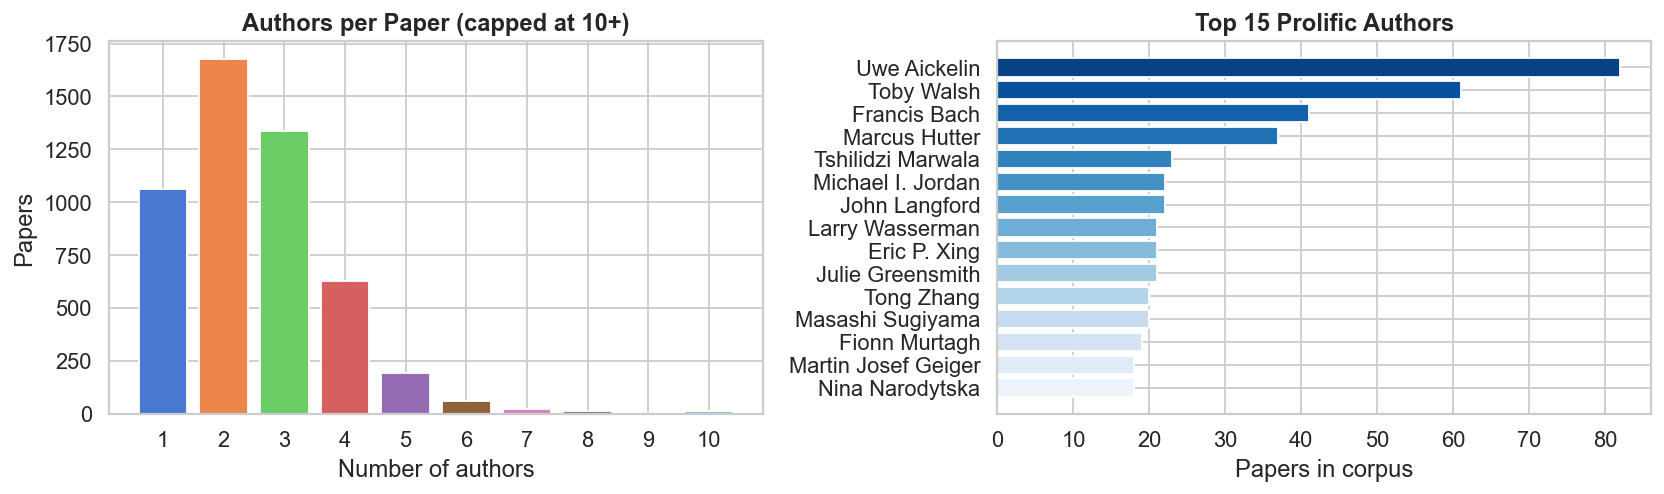

Saved: 04_author_statistics.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Authors per paper
ax = axes[0]
co_counts = df["author_count"].clip(upper=10).value_counts().sort_index()
ax.bar(co_counts.index.astype(str), co_counts.values,
       color=sns.color_palette("muted", len(co_counts)), edgecolor="white")
ax.set_title("Authors per Paper (capped at 10+)", fontweight="bold")
ax.set_xlabel("Number of authors"); ax.set_ylabel("Papers")

# Top 15 prolific authors
all_authors: list[str] = []
for authors in df["authors"]:
    all_authors.extend(authors)
top_authors = pd.Series(Counter(all_authors)).nlargest(15)
colors_auth = sns.color_palette("Blues_r", len(top_authors))
axes[1].barh(top_authors.index[::-1], top_authors.values[::-1], color=colors_auth[::-1])
axes[1].set_title("Top 15 Prolific Authors", fontweight="bold")
axes[1].set_xlabel("Papers in corpus")

print(f"Unique authors: {len(set(all_authors)):,}")
print(f"Single-author papers: {(df['author_count']==1).sum():,} "
      f"({(df['author_count']==1).mean()*100:.1f}%)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_author_statistics.png")
plt.show()
print("Saved: 04_author_statistics.png")


## 8. Missing-data audit

Transparency about sparsity is required for the report's Data section and
justifies the Semantic Scholar enrichment step.


          Field  Present  Missing  % Present
            DOI     1098     3902       22.0
Venue / journal     1708     3292       34.2
     TL;DR (S2)        0     5000        0.0
    S2-enriched        0     5000        0.0
 Published date     5000        0      100.0
   Authors list     5000        0      100.0
       Abstract     5000        0      100.0


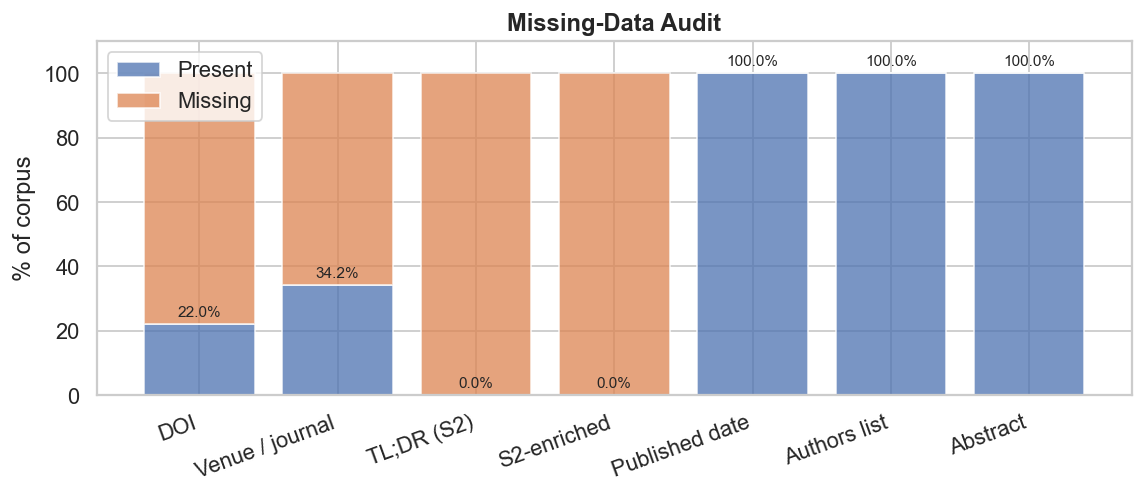

Saved: 05_missing_data_audit.png


In [8]:
fields_to_audit = {
    "DOI":           df["has_doi"],
    "Venue / journal": df["has_venue"],
    "TL;DR (S2)":    df["has_tldr"] if "has_tldr" in df.columns else pd.Series([False]*len(df)),
    "S2-enriched":   df["s2_enriched"],
    "Published date":df["published_date"].notna() & (df["published_date"] != ""),
    "Authors list":  df["author_count"] > 0,
    "Abstract":      df["abstract_len"] > 0,
}

audit = pd.DataFrame({
    "Field":    list(fields_to_audit.keys()),
    "Present":  [int(v.sum()) for v in fields_to_audit.values()],
    "Missing":  [int((~v).sum()) for v in fields_to_audit.values()],
    "% Present":[round(v.mean()*100, 1) for v in fields_to_audit.values()],
})
print(audit.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(audit))
ax.bar(x, audit["% Present"], color="#4C72B0", alpha=0.75, label="Present")
ax.bar(x, [100-v for v in audit["% Present"]], bottom=audit["% Present"],
       color="#DD8452", alpha=0.75, label="Missing")
ax.set_xticks(list(x)); ax.set_xticklabels(audit["Field"], rotation=20, ha="right")
ax.set_ylabel("% of corpus"); ax.set_title("Missing-Data Audit", fontweight="bold")
ax.set_ylim(0, 110); ax.legend()
for i, row in audit.iterrows():
    ax.text(i, row["% Present"] + 1.5, f"{row['% Present']}%",
            ha="center", va="bottom", fontsize=8.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_missing_data_audit.png")
plt.show()
print("Saved: 05_missing_data_audit.png")


## 9. Vocabulary analysis & word cloud

Surface the dominant research themes in the corpus — feeds the report's 
dataset description and validates that the scope (NLP/AI/ML) is coherent.


Vocabulary size (≥3 chars, no stopwords): 18,682
Top 20 terms:
  algorithm            2,941
  learning             2,781
  problem              2,582
  algorithms           1,726
  information          1,690
  problems             1,584
  time                 1,398
  system               1,361
  number               1,274
  present              1,240
  performance          1,206
  analysis             1,159
  where                1,075
  different            1,048
  many                 1,032
  other                1,007
  function             985
  framework            945
  systems              907
  how                  876


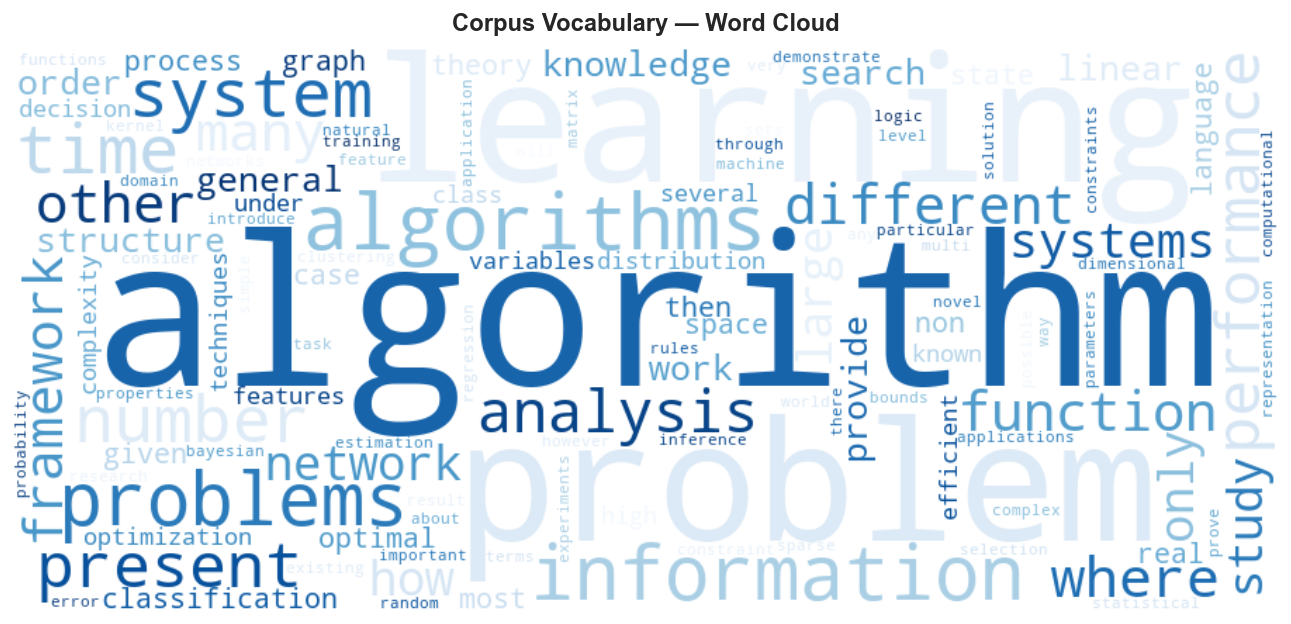

Saved: 06_wordcloud.png


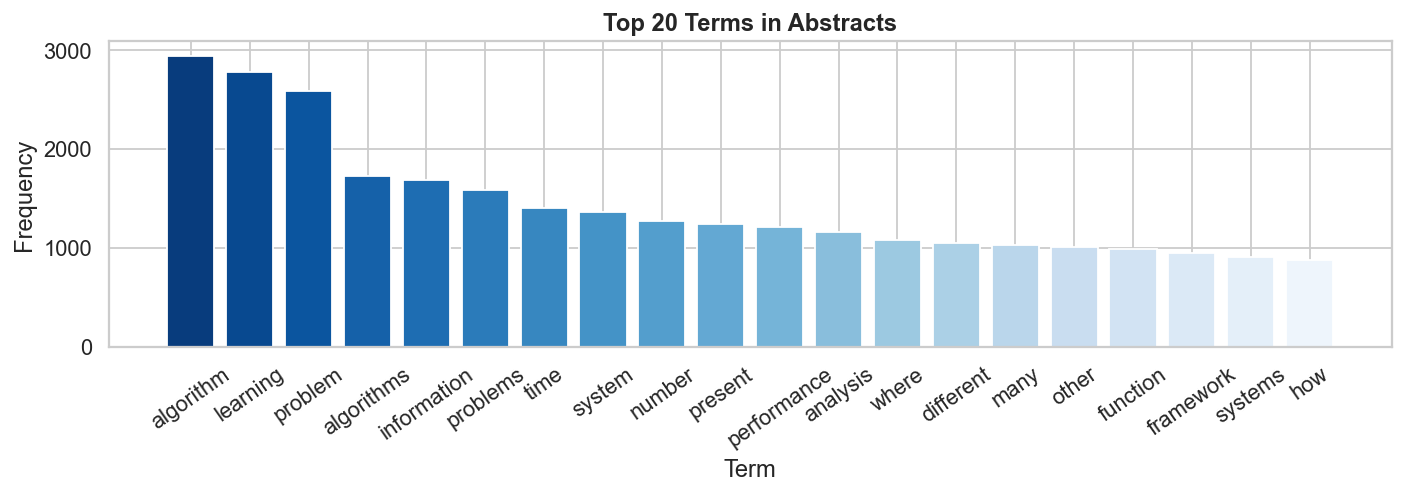

Saved: 07_top20_terms.png


In [9]:
import re as _re

STOPWORDS = {
    "the","a","an","of","in","for","to","and","is","are","we","our","this",
    "that","with","on","by","from","as","be","it","at","which","using","used",
    "can","also","show","shows","propose","proposed","paper","method","methods",
    "approach","approaches","based","model","models","data","results","new",
    "two","one","first","each","both","their","has","have","these","than",
    "more","between","while","into","its","not","but","or","all","been",
    "such","they","over","when","some","set","use","via","per","may","well",
}

def tokenise_abstracts(series: pd.Series) -> list[str]:
    tokens = []
    for text in series.dropna():
        words = _re.findall(r"[a-zA-Z]{3,}", text.lower())
        tokens.extend(w for w in words if w not in STOPWORDS)
    return tokens

tokens     = tokenise_abstracts(df["abstract"])
freq       = Counter(tokens)
vocab_size = len(freq)
print(f"Vocabulary size (≥3 chars, no stopwords): {vocab_size:,}")
print("Top 20 terms:")
for term, cnt in freq.most_common(20):
    print(f"  {term:<20} {cnt:,}")

# Word cloud
wc = WordCloud(width=900, height=400, background_color="white",
               colormap="Blues", max_words=120,
               min_font_size=10).generate_from_frequencies(freq)
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off"); ax.set_title("Corpus Vocabulary — Word Cloud", fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_wordcloud.png")
plt.show()
print("Saved: 06_wordcloud.png")

# Top-20 bar chart
top20 = pd.Series(dict(freq.most_common(20)))
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(top20.index, top20.values,
       color=sns.color_palette("Blues_r", len(top20)))
ax.set_title("Top 20 Terms in Abstracts", fontweight="bold")
ax.set_xlabel("Term"); ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_top20_terms.png")
plt.show()
print("Saved: 07_top20_terms.png")


## 10. Citation distribution (post-enrichment)

Only available after Stage 02b S2 enrichment. The cell gracefully skips if the
enriched corpus isn't present yet.


In [10]:
if df["s2_enriched"].any():
    enr = df[df["s2_enriched"]]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Citation count histogram (log scale)
    axes[0].hist(enr["citation_count"].clip(upper=500), bins=50,
                 color="#4C72B0", edgecolor="white", alpha=0.8)
    axes[0].set_title("Citation Count Distribution (capped at 500)", fontweight="bold")
    axes[0].set_xlabel("Citations"); axes[0].set_ylabel("Papers")
    axes[0].axvline(enr["citation_count"].median(), color="red", linestyle="--",
                    label=f"Median ({int(enr['citation_count'].median())})")
    axes[0].legend()

    # Influential citations vs total
    axes[1].scatter(enr["citation_count"], enr["influential_citation_count"],
                    alpha=0.4, s=18, color="#DD8452")
    axes[1].set_title("Influential vs Total Citations", fontweight="bold")
    axes[1].set_xlabel("Total citations"); axes[1].set_ylabel("Influential citations")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "08_citation_distribution.png")
    plt.show()
    print("Saved: 08_citation_distribution.png")
    print(f"\nCitation stats (enriched subset of {len(enr):,} papers):")
    print(enr[["citation_count","influential_citation_count","ref_count"]]
            .describe().round(1).to_string())
else:
    print("Enrichment not yet run — skipping citation plots.")
    print("Re-run after Stage 02b (enrich_corpus) to generate these figures.")


Enrichment not yet run — skipping citation plots.
Re-run after Stage 02b (enrich_corpus) to generate these figures.


## 11. Dataset limitations (report-ready)

Written as Markdown so it can be copied directly into the report's
*Data and Evaluation* section.


In [11]:
limitations_text = """## Dataset Limitations

### 1. Scope is CS/ML-only, not broad STEM
The corpus is restricted to `cs.CL`, `cs.AI`, `cs.LG`, and `stat.ML`.
Papers in physics, biology, chemistry, or engineering are excluded.
This makes the recommendation system domain-specific; cross-domain
retrieval is out of scope for the current system.

### 2. Abstracts only — no full text
The Kaggle arXiv dump provides only titles, abstracts, and metadata.
Full paper bodies (methods, results, figures, tables) are unavailable.
This limits extractive summarisation quality and means the system cannot
reason about experimental details or figure content.
*(Multimodal figure/table understanding is noted as a planned future extension.)*

### 3. Sparse metadata
A significant proportion of records lack DOI and venue fields, as the raw
Kaggle dump reflects the arXiv pre-print state of papers (many never
formally published, or journal-ref not updated). Semantic Scholar
enrichment partially mitigates this but is not exhaustive.

### 4. Label imbalance
The primary-category distribution is uneven (cs.LG > cs.CL > cs.AI >
stat.ML in most time windows). Classifiers trained without rebalancing
will be biased toward cs.LG. We address this with class-weighted loss
in Stages 05–06.

### 5. Temporal bias
The subset is sampled in file order, which skews toward older papers
(the Kaggle dump is roughly chronological). Recent papers (2023–2024)
are underrepresented relative to their actual volume in arXiv.
A production system should use stratified temporal sampling.

### 6. Citation lag
Citation counts from Semantic Scholar reflect the state at enrichment
time. Newly published papers will have artificially low counts,
depressing their recommendation ranking. Time-normalised citation
scores (citations per year) would partially correct this.

### 7. No author disambiguation
Author names are taken as-is from the structured `authors_parsed` field.
Name collisions (same name, different researcher) and variants (initials
vs full name) are not resolved. This affects the prolific-author
statistics and citation-graph construction.
"""

LIMITS_MD.write_text(limitations_text, encoding="utf-8")
print(limitations_text)
print(f"\nSaved: {LIMITS_MD}")


## Dataset Limitations

### 1. Scope is CS/ML-only, not broad STEM
The corpus is restricted to `cs.CL`, `cs.AI`, `cs.LG`, and `stat.ML`.
Papers in physics, biology, chemistry, or engineering are excluded.
This makes the recommendation system domain-specific; cross-domain
retrieval is out of scope for the current system.

### 2. Abstracts only — no full text
The Kaggle arXiv dump provides only titles, abstracts, and metadata.
Full paper bodies (methods, results, figures, tables) are unavailable.
This limits extractive summarisation quality and means the system cannot
reason about experimental details or figure content.
*(Multimodal figure/table understanding is noted as a planned future extension.)*

### 3. Sparse metadata
A significant proportion of records lack DOI and venue fields, as the raw
Kaggle dump reflects the arXiv pre-print state of papers (many never
formally published, or journal-ref not updated). Semantic Scholar
enrichment partially mitigates this but is not exhaustive.


## 12. EDA Summary & handoff

In [12]:
print("=" * 55)
print("  STAGE 03 EDA — SUMMARY")
print("=" * 55)
print(f"  Corpus:         {corpus_path.name}")
print(f"  Records:        {len(df):,}")
print(f"  Year range:     {year_range}")
print(f"  Primary cats:   {', '.join(df['primary_cat'].value_counts().index.tolist())}")
print(f"  Avg abstract:   {df['abstract_len'].mean():.0f} words")
print(f"  Vocab size:     {vocab_size:,} unique terms")
print(f"  Figures saved:  {len(list(FIGURES_DIR.glob('*.png')))}")
print(f"  Limitations:    {LIMITS_MD}")
print()
print("Downstream use:")
print("  - Figures  → report Section: Data and Evaluation")
print("  - Limitations note → report Section: Recommendation & Discussion")
print("  - Vocab stats → Stage 04 preprocessing (stopword list, token budget)")
print("  - Label counts → Stage 05 class-weight calculation for classifiers")
print("=" * 55)


  STAGE 03 EDA — SUMMARY
  Corpus:         dev_5k.jsonl
  Records:        5,000
  Year range:     2007 – 2012
  Primary cats:   cs.AI, cs.LG, stat.ML, cs.CL, cs.NE, cs.CV, cs.IT, stat.ME, math.ST, cs.LO, cs.IR, cs.DS, math.OC, cs.GT, cs.DB, cs.SI, stat.CO, cs.MA, physics.data-an, cs.NI, cs.CC, physics.soc-ph, cs.SE, stat.AP, math.PR, cs.RO, cs.HC, quant-ph, q-bio.NC, cs.CR, cond-mat.dis-nn, cs.PL, cs.CY, q-bio.QM, cs.SY, cs.CE, cs.DL, cond-mat.stat-mech, cs.NA, nlin.AO, cs.DC, q-bio.PE, cs.DM, cs.SD, cs.FL, astro-ph.IM, cs.MM, math.LO, cs.CG, math.NA, math.CO, cs.GR, q-bio.GN, math.FA, q-bio.MN, q-fin.TR, astro-ph.CO, stat.OT, cs.SC, math.CT, cs.AR, q-fin.ST, nlin.CG, nlin.PS, nlin.CD, cs.MS, nucl-th, astro-ph, physics.ins-det, math.KT, cs.OH, math.AP, astro-ph.GA, math.GT, q-fin.PM, cs.PF, physics.bio-ph, math.HO, math-ph, math.MG, q-fin.GN, physics.hist-ph, physics.ed-ph, physics.chem-ph, cs.ET, physics.comp-ph, physics.ao-ph, q-fin.RM
  Avg abstract:   143 words
  Vocab size:     18

## Next stages (Yash's track)
- **Stage 04** — Text preprocessing pipeline (tokenisation, LaTeX cleanup, lemmatisation)
- **Stage 05** — TF-IDF + Logistic Regression / SVM baselines
- **Stage 06** — SPECTER2 classification (neural baseline)
- **Stage 07** — Reproducible sample + data card
- **Stage 08** — Evaluation tables & handoff
